# Week 5 — NLP & Sentiment Analysis

**Objective:** Teach a machine to read Amazon customer reviews and predict whether each is **positive** or **negative**. Part 1 (this notebook) cleans the raw text, turns it into numbers, trains and compares two classifiers, and saves the best one. Part 2 wraps it in a Streamlit dashboard where anyone can type a review and get an instant sentiment prediction.

**Dataset:** Amazon product (Alexa) reviews — thousands of real reviews with a text column (`verified_reviews`) and a binary sentiment label (`feedback`: 1 = positive, 0 = negative).

## 1. Setup

In [1]:
import re, os, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from wordcloud import WordCloud

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

## 2. Load the Data and Inspect Text + Label Columns

In [2]:
CANDIDATES = ['data/reviews.csv', 'reviews.csv', 'DataSet (W5).csv', 'data/DataSet (W5).csv', 'amazon_alexa.tsv']
path = next((p for p in CANDIDATES if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError('Upload the reviews dataset (DataSet (W5).csv) into the working directory or data/.')

sep = '\t' if path.endswith('.tsv') else ','
df = pd.read_csv(path, sep=sep)
print('Loaded:', path, '| shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Loaded: DataSet (W5).csv | shape: (3150, 5)
Columns: ['rating', 'date', 'variation', 'verified_reviews', 'feedback']


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [3]:
# Identify the review-text column and the sentiment-label column
TEXT_COL = 'verified_reviews' if 'verified_reviews' in df.columns else \
           next(c for c in df.columns if df[c].dtype == object and df[c].astype(str).str.len().mean() > 15)
LABEL_COL = 'feedback' if 'feedback' in df.columns else \
            next(c for c in df.columns if df[c].nunique() == 2)
print('Text column :', TEXT_COL)
print('Label column:', LABEL_COL)

# Keep only the two columns we need, drop empty reviews
data = df[[TEXT_COL, LABEL_COL]].dropna()
data = data[data[TEXT_COL].astype(str).str.strip() != '']
data.columns = ['review', 'sentiment']
data['sentiment'] = data['sentiment'].astype(int)
print('\nUsable rows:', len(data))
data.head()

Text column : verified_reviews
Label column: feedback

Usable rows: 3070


,review,sentiment
0,Love my Echo!,1
1,Loved it!,1
2,"Sometimes while playing a game, you can answer...",1
3,I have had a lot of fun with this thing. My 4 ...,1
4,Music,1


## 3. Class Distribution

Checking how many positive vs negative reviews there are — this matters a lot for choosing the right evaluation metric.

Class counts (0 = negative, 1 = positive):
sentiment
0     237
1    2833
Name: count, dtype: int64

Positive share: 92.3%


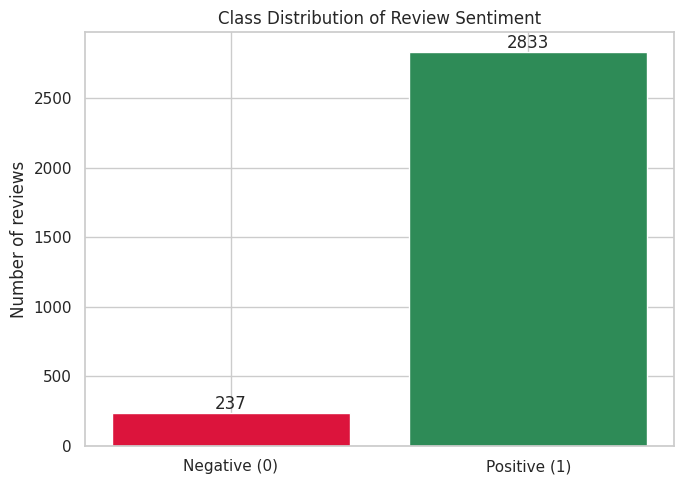

In [4]:
counts = data['sentiment'].value_counts().sort_index()
print('Class counts (0 = negative, 1 = positive):')
print(counts)
print(f'\nPositive share: {data["sentiment"].mean():.1%}')

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=['crimson', 'seagreen'])
ax.bar_label(bars)
ax.set_title('Class Distribution of Review Sentiment')
ax.set_ylabel('Number of reviews')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

data.to_csv('class_counts_helper.csv', index=False)  # (full data kept for the app's Data Overview page)

**Observation:** the data is heavily **imbalanced** — the large majority of reviews are positive. Because of this I will not rely on plain accuracy (a model that always predicts "positive" would already look ~92% accurate). I use **macro-F1** and per-class precision/recall, and give the models `class_weight='balanced'` so the small negative class still matters.

## 4. Clean the Raw Text

**Cleaning steps** (applied by one reusable `clean_text` function so Part 1 and the Part 2 app clean text identically):
1. lowercase everything;
2. strip HTML tags, URLs and anything that is not a letter or space (removes numbers, punctuation, emojis);
3. split into words and drop **stopwords** (common words like *the, is, and* that carry no sentiment) using scikit-learn's built-in English stopword list;
4. drop very short tokens (1–2 letters).

Stopwords come from `sklearn`'s `ENGLISH_STOP_WORDS` so no external download is needed and the app reproduces cleaning exactly.

In [5]:
STOPWORDS = set(ENGLISH_STOP_WORDS)

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)                 # HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # URLs
    text = re.sub(r'[^a-z\s]', ' ', text)              # keep letters only
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

data['clean'] = data['review'].apply(clean_text)
data = data[data['clean'].str.strip() != '']  # drop rows that became empty after cleaning
print('Example:')
print('RAW  :', data['review'].iloc[3][:120])
print('CLEAN:', data['clean'].iloc[3][:120])
print('\nRows after cleaning:', len(data))

Example:
RAW  : I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games like ca
CLEAN: lot fun thing old learns dinosaurs control lights play games like categories nice sound playing music

Rows after cleaning: 3058


## 5. Word Clouds — Positive vs Negative Reviews

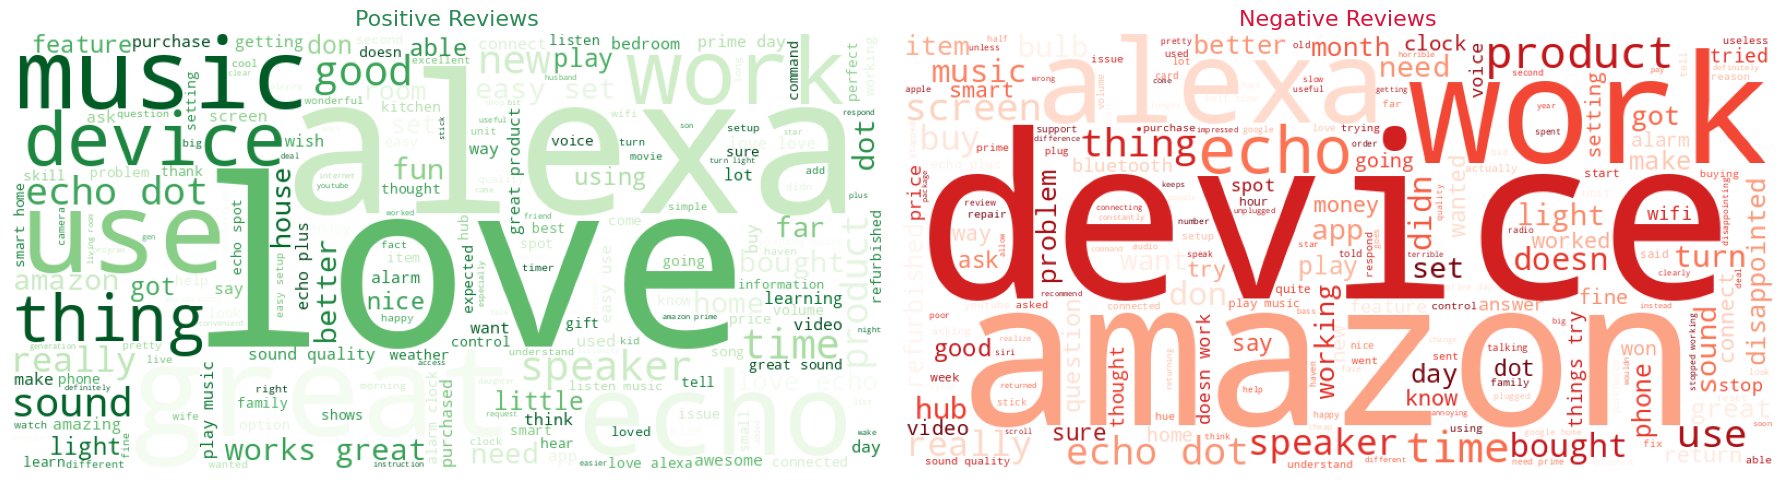

In [6]:
pos_text = ' '.join(data.loc[data['sentiment'] == 1, 'clean'])
neg_text = ' '.join(data.loc[data['sentiment'] == 0, 'clean'])

wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(wc_pos); axes[0].axis('off'); axes[0].set_title('Positive Reviews', fontsize=16, color='seagreen')
axes[1].imshow(wc_neg); axes[1].axis('off'); axes[1].set_title('Negative Reviews', fontsize=16, color='crimson')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=110, bbox_inches='tight')
plt.show()

wc_pos.to_file('wordcloud_positive.png')
wc_neg.to_file('wordcloud_negative.png')

**Observation:** positive reviews are dominated by words like *love, great, easy, music, alexa*, while negative reviews feature *work, return, product, disappointed, device* — the two vocabularies are visibly different, which is exactly why a text classifier can separate them.

## 6. Vectorization — TF-IDF

**Why TF-IDF?** A model can't read words, only numbers. TF-IDF (Term Frequency–Inverse Document Frequency) turns each review into a vector where each word's weight is high if it appears often **in that review** but rarely **across all reviews**. This automatically plays down common words and plays up distinctive, informative ones (*disappointed*, *refund*, *love*). It's the standard, fast, strong baseline for sentiment classification and pairs excellently with linear models. I limit to the top 5,000 terms and include bigrams (1–2 word phrases) so short negation phrases like *not good* are captured.

In [7]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(data['clean'])
y = data['sentiment'].values
print('TF-IDF feature matrix:', X.shape, '(reviews x features)')

TF-IDF feature matrix: (3058, 5000) (reviews x features)


## 7. Train/Test Split and Two Classifiers

An 80/20 **stratified** split keeps the same positive/negative ratio in both sets. Two models are trained: **Logistic Regression** (a strong, interpretable linear model, `class_weight='balanced'` for the imbalance) and **Multinomial Naive Bayes** (the classic fast text-classification baseline).

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_train.shape[0], ' Test:', X_test.shape[0])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Multinomial Naive Bayes': MultinomialNB(),
}

results = {}
preds = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    preds[name] = pred
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision (macro)': precision_score(y_test, pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_test, pred, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_test, pred, average='macro', zero_division=0),
    }
    print(f'\n=== {name} ===')
    print(classification_report(y_test, pred, target_names=['Negative', 'Positive'], zero_division=0))

res_df = pd.DataFrame(results).T
res_df.round(4)

Train: 2446  Test: 612

=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.54      0.81      0.64        47
    Positive       0.98      0.94      0.96       565

    accuracy                           0.93       612
   macro avg       0.76      0.88      0.80       612
weighted avg       0.95      0.93      0.94       612


=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

    Negative       1.00      0.02      0.04        47
    Positive       0.92      1.00      0.96       565

    accuracy                           0.92       612
   macro avg       0.96      0.51      0.50       612
weighted avg       0.93      0.92      0.89       612



,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Logistic Regression,0.9314,0.7593,0.8751,0.8030
Multinomial Naive Bayes,0.9248,0.9624,0.5106,0.5013


## 8. Confusion Matrix for Each Model

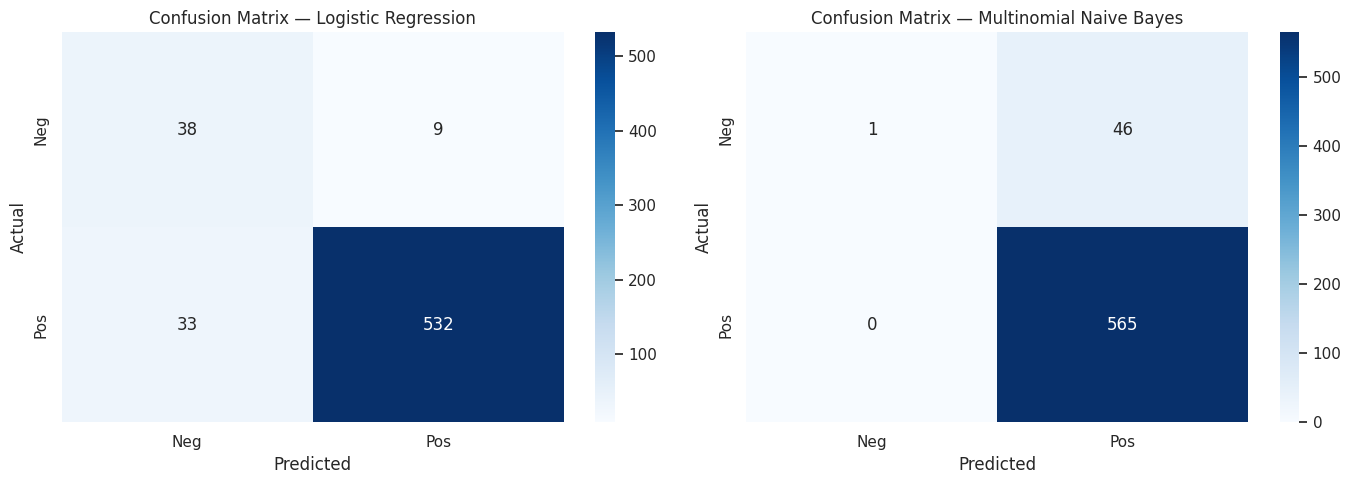

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Compare Models and Save the Best

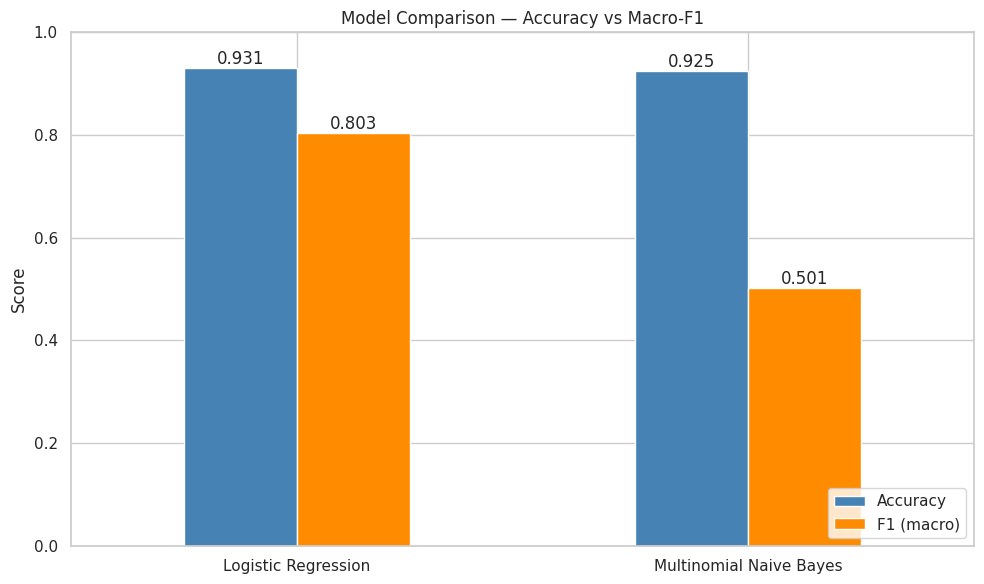

Best model by macro-F1: Logistic Regression


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
res_df[['Accuracy', 'F1 (macro)']].plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'])
ax.set_title('Model Comparison — Accuracy vs Macro-F1')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_xticklabels(res_df.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

# Best model chosen by macro-F1 (fairer than accuracy on imbalanced data)
best_name = res_df['F1 (macro)'].idxmax()
best_model = models[best_name]
print('Best model by macro-F1:', best_name)

In [ ]:
ooks/

In [11]:
# Save the best model AND the vectorizer together so the app can reproduce predictions
joblib.dump({'model': best_model, 'vectorizer': vectorizer, 'best_name': best_name},
            'sentiment_model.joblib', compress=3)
size = os.path.getsize('sentiment_model.joblib') / 1e6
print(f'Saved sentiment_model.joblib ({size:.2f} MB) — contains {best_name} + TF-IDF vectorizer')

# Quick sanity check: predict on two new sentences
def predict(text):
    v = vectorizer.transform([clean_text(text)])
    label = best_model.predict(v)[0]
    prob = best_model.predict_proba(v)[0].max()
    return ('Positive' if label == 1 else 'Negative', round(prob, 3))

print(predict('This product is amazing, I absolutely love it!'))
print(predict('Terrible. It stopped working after two days and I want a refund.'))

Saved sentiment_model.joblib (0.09 MB) — contains Logistic Regression + TF-IDF vectorizer
('Positive', np.float64(0.928))
('Negative', np.float64(0.942))


In [12]:
# Bundle every artifact the Streamlit app and the LinkedIn post need
import zipfile
with zipfile.ZipFile('week5_assets.zip', 'w') as z:
    for f in ['sentiment_model.joblib', 'class_distribution.png', 'wordclouds.png',
              'wordcloud_positive.png', 'wordcloud_negative.png',
              'confusion_matrices.png', 'model_comparison.png']:
        if os.path.exists(f):
            z.write(f)
print('week5_assets.zip created:', round(os.path.getsize('week5_assets.zip')/1e6, 2), 'MB')

week5_assets.zip created: 1.21 MB


## 10. Summary

Starting from raw Amazon reviews I cleaned the text, visualised the positive vs negative vocabulary with word clouds, converted the reviews into TF-IDF features (unigrams + bigrams), and trained two classifiers. Because the data is heavily positive-skewed I judged them on **macro-F1** rather than accuracy and used balanced class weights. The stronger model, together with its vectorizer, is saved as `sentiment_model.joblib` and is loaded by the Streamlit dashboard in Part 2, which applies the *same* `clean_text` function before predicting so training and serving stay consistent.